In [47]:
# Uncommnent if you need to install the packages
# %pip install geopandas kagglehub
# update kagglehub to the latest version
# %pip install --upgrade kagglehub

# Load the dataset

Loading the extracted geopackage (.gpkg) of the extracted data using `wosis-data-selector` script without any filters except for 0-30cm depth.

In [1]:
import geopandas as gpd
# master file
wosis_raw = "wosis_202312_unfiltered"
mexio_wosis_gdf = f"D:/tierra/outputs/unfiltered/wosis_202312_unfiltered.csv"
mexio_wosis_gdf = gpd.read_file(mexio_wosis_gdf)

#
print(f"Number of records in the raw WOSIS file: {len(mexio_wosis_gdf)}")
print(f"Number of unique profiles in the raw WOSIS file: {len(mexio_wosis_gdf['profile_id'].unique())}")
print(f"Number of columns in the raw WOSIS file: {len(mexio_wosis_gdf.columns)}")
print(f"List of columns in the raw WOSIS file: {list(mexio_wosis_gdf.columns)}")

mexio_wosis_gdf.head()

Number of records in the raw WOSIS file: 87364
Number of unique profiles in the raw WOSIS file: 7541
Number of columns in the raw WOSIS file: 33
List of columns in the raw WOSIS file: ['profile_id', 'latitude', 'longitude', 'upper_depth', 'lower_depth', 'date', 'bdfi33', 'bdfiod', 'bdwsod', 'cecph7', 'cfgr', 'cfvo', 'clay', 'ecec', 'elco20', 'elcosp', 'nitkjd', 'orgc', 'phaq', 'phca', 'phetb1', 'phkc', 'phnf', 'phprtn', 'sand', 'silt', 'tceq', 'totc', 'wg0006', 'wg0010', 'wg0033', 'wg0200', 'wg1500']


,profile_id,latitude,longitude,upper_depth,lower_depth,date,bdfi33,bdfiod,bdwsod,cecph7,...,phprtn,sand,silt,tceq,totc,wg0006,wg0010,wg0033,wg0200,wg1500
0,1147760,18.1980553,-91.5366669,0,5,1991-11-4,1.33,1.84,,40.5,...,30.0,11.9,35.7,,30.2,,32.4,32.4,32.4,25.9
1,1147760,18.1980553,-91.5366669,5,20,1991-11-4,,,,,...,,,24.2,,,,,,,
2,1147760,18.1980553,-91.5366669,5,24,1991-11-4,1.21,1.87,,38.0,...,30.0,11.4,34.4,,11.2,,,37.9,31.5,23.8
3,1147760,18.1980553,-91.5366669,24,45,1991-11-4,1.2,,,42.2,...,45.0,9.8,30.0,,5.1,,37.4,36.3,34.5,28.3
4,1147760,18.1980553,-91.5366669,45,68,1991-11-4,1.16,2.11,,50.5,...,46.0,6.9,21.4,,3.6,,45.0,43.5,37.9,29.0


# Preprocessing the dataset

In [4]:
# drop selected columns irrelevant to model training
if 'country_name' in mexio_wosis_gdf.columns:
    mexio_wosis_gdf.drop(columns=['country_name'], inplace=True)
    print(f"Shape of the dataset: {mexio_wosis_gdf.shape}")

In [5]:
# Copy dataset to have target values as orgc and tceq
orgc_df = mexio_wosis_gdf.drop(columns=['tceq']).copy() # drop tceq column
tceq_df = mexio_wosis_gdf.drop(columns=['orgc']).copy() # drop orgc column

In [6]:
print(f"Shape of the orgc dataset: {orgc_df.shape}")
orgc_df.head()

Shape of the orgc dataset: (87364, 32)


,profile_id,latitude,longitude,upper_depth,lower_depth,date,bdfi33,bdfiod,bdwsod,cecph7,...,phnf,phprtn,sand,silt,totc,wg0006,wg0010,wg0033,wg0200,wg1500
0,1147760,18.1980553,-91.5366669,0,5,1991-11-4,1.33,1.84,,40.5,...,,30.0,11.9,35.7,30.2,,32.4,32.4,32.4,25.9
1,1147760,18.1980553,-91.5366669,5,20,1991-11-4,,,,,...,,,,24.2,,,,,,
2,1147760,18.1980553,-91.5366669,5,24,1991-11-4,1.21,1.87,,38.0,...,,30.0,11.4,34.4,11.2,,,37.9,31.5,23.8
3,1147760,18.1980553,-91.5366669,24,45,1991-11-4,1.2,,,42.2,...,,45.0,9.8,30.0,5.1,,37.4,36.3,34.5,28.3
4,1147760,18.1980553,-91.5366669,45,68,1991-11-4,1.16,2.11,,50.5,...,,46.0,6.9,21.4,3.6,,45.0,43.5,37.9,29.0


In [7]:
tceq_df.head()
print(f"Shape of the tceq dataset: {orgc_df.shape}")

Shape of the tceq dataset: (87364, 32)


In [8]:
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def preprocessor(df, target):
    logger.info(f"Initial number of records: {len(df)}")
    logger.info(f"Initial number of columns: {len(df.columns)}")
    # drop the missing values in the target column
    df = df.dropna(subset=[target])
    logger.info(f"Number of records after dropping missing values in the target column: {len(df)}")
    # drop the columns with more than 60% missing values
    df = df.dropna(thresh=len(df) * 0.7, axis=1)
    logger.info(f"Number of columns after dropping columns with more than 60% missing values: {len(df.columns)}")
    # drop the other missing values
    df = df.dropna()
    logger.info(f"Number of records after dropping other missing values: {len(df)}")
    # drop the duplicates
    df = df.drop_duplicates()
    logger.info(f"Number of records after dropping duplicates: {len(df)}")

    return df

def plot_missing_values(df, target):
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Calculate missing values percentage
    missing_values = (df.isnull().sum() / len(df)) * 100
    missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

    if len(missing_values) == 0:
        logger.warning("No missing values found in the dataset")
        return

    # Create the plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_values.values, y=missing_values.index, palette='viridis')
    
    # Customize the plot
    plt.title(f'Missing Values in Dataset (Target: {target})')
    plt.xlabel('Percentage of Missing Values')
    plt.ylabel('Features')
    plt.grid(axis='x')

    # Add percentage labels on bars
    for i, v in enumerate(missing_values.values):
        plt.text(v + 1, i, f'{v:.1f}%', va='center')

    plt.tight_layout()
    plt.show()

In [9]:
# Preprocess the orgc_df and tceq_df dataframes
orgc_df = preprocessor(orgc_df, target='orgc')

plot_missing_values(orgc_df, 'orgc')

orgc_df.head()

INFO - Initial number of records: 87364
INFO - Initial number of columns: 32
INFO - Number of records after dropping missing values in the target column: 87364
INFO - Number of columns after dropping columns with more than 60% missing values: 32
INFO - Number of records after dropping other missing values: 87364
INFO - Number of records after dropping duplicates: 30020
WARNING - No missing values found in the dataset


,profile_id,latitude,longitude,upper_depth,lower_depth,date,bdfi33,bdfiod,bdwsod,cecph7,...,phnf,phprtn,sand,silt,totc,wg0006,wg0010,wg0033,wg0200,wg1500
0,1147760,18.1980553,-91.5366669,0,5,1991-11-4,1.33,1.84,,40.5,...,,30.0,11.9,35.7,30.2,,32.4,32.4,32.4,25.9
1,1147760,18.1980553,-91.5366669,5,20,1991-11-4,,,,,...,,,,24.2,,,,,,
2,1147760,18.1980553,-91.5366669,5,24,1991-11-4,1.21,1.87,,38.0,...,,30.0,11.4,34.4,11.2,,,37.9,31.5,23.8
3,1147760,18.1980553,-91.5366669,24,45,1991-11-4,1.2,,,42.2,...,,45.0,9.8,30.0,5.1,,37.4,36.3,34.5,28.3
4,1147760,18.1980553,-91.5366669,45,68,1991-11-4,1.16,2.11,,50.5,...,,46.0,6.9,21.4,3.6,,45.0,43.5,37.9,29.0


In [10]:
# Preprocess the orgc_df and tceq_df dataframes
tceq_df = preprocessor(tceq_df, target='tceq')

plot_missing_values(tceq_df, 'tceq')

tceq_df.head()

INFO - Initial number of records: 87364
INFO - Initial number of columns: 32
INFO - Number of records after dropping missing values in the target column: 87364
INFO - Number of columns after dropping columns with more than 60% missing values: 32
INFO - Number of records after dropping other missing values: 87364
INFO - Number of records after dropping duplicates: 30020
WARNING - No missing values found in the dataset


,profile_id,latitude,longitude,upper_depth,lower_depth,date,bdfi33,bdfiod,bdwsod,cecph7,...,phprtn,sand,silt,tceq,totc,wg0006,wg0010,wg0033,wg0200,wg1500
0,1147760,18.1980553,-91.5366669,0,5,1991-11-4,1.33,1.84,,40.5,...,30.0,11.9,35.7,,30.2,,32.4,32.4,32.4,25.9
1,1147760,18.1980553,-91.5366669,5,20,1991-11-4,,,,,...,,,24.2,,,,,,,
2,1147760,18.1980553,-91.5366669,5,24,1991-11-4,1.21,1.87,,38.0,...,30.0,11.4,34.4,,11.2,,,37.9,31.5,23.8
3,1147760,18.1980553,-91.5366669,24,45,1991-11-4,1.2,,,42.2,...,45.0,9.8,30.0,,5.1,,37.4,36.3,34.5,28.3
4,1147760,18.1980553,-91.5366669,45,68,1991-11-4,1.16,2.11,,50.5,...,46.0,6.9,21.4,,3.6,,45.0,43.5,37.9,29.0


In [11]:
import os

def save_to_dataset(df, filename):
    datasets_path = f"D:/tierra/datasets/{wosis_raw}_cleaned_{filename}.csv"
    
    # make sure the directory exists
    os.makedirs(os.path.dirname(datasets_path), exist_ok=True)

    # sve the file
    df.to_csv(datasets_path, index=False)

    # log the file path
    print(f"Dataset {filename} saved to {datasets_path}")

# no more missing data proceed to save the datasets
save_to_dataset(orgc_df, "orgc")
save_to_dataset(tceq_df, "tceq")

Dataset orgc saved to D:/tierra/datasets/wosis_202312_unfiltered_cleaned_orgc.csv
Dataset tceq saved to D:/tierra/datasets/wosis_202312_unfiltered_cleaned_tceq.csv


# Depths Analysis

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_scatter(df, x_col='upper_depth', y_col='lower_depth', title='Depth Distribution by Profile'):
    plt.figure(figsize=(12, 8))
    
    # Create scatter plot with profile_id as color
    scatter = plt.scatter(df[x_col], df[y_col], 
                         c=df['profile_id'].astype('category').cat.codes,
                         alpha=0.6, 
                         cmap='tab20',
                         s=50,
                         label='Soil samples')  # Add label
    
    plt.title(title)
    plt.xlabel('Upper Depth (cm)')
    plt.ylabel('Lower Depth (cm)')
    plt.grid(True, alpha=0.3)
    
    plt.colorbar(scatter, label='Profile ID (categorical)')
    plt.show()

INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


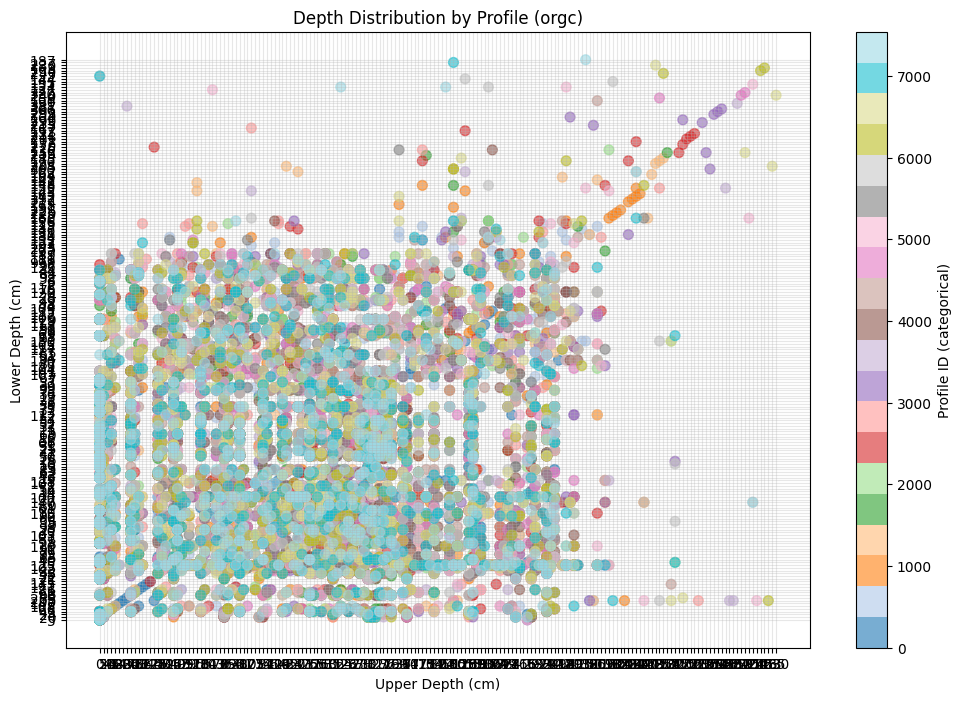

In [13]:
plot_scatter(orgc_df, title='Depth Distribution by Profile (orgc)')

INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


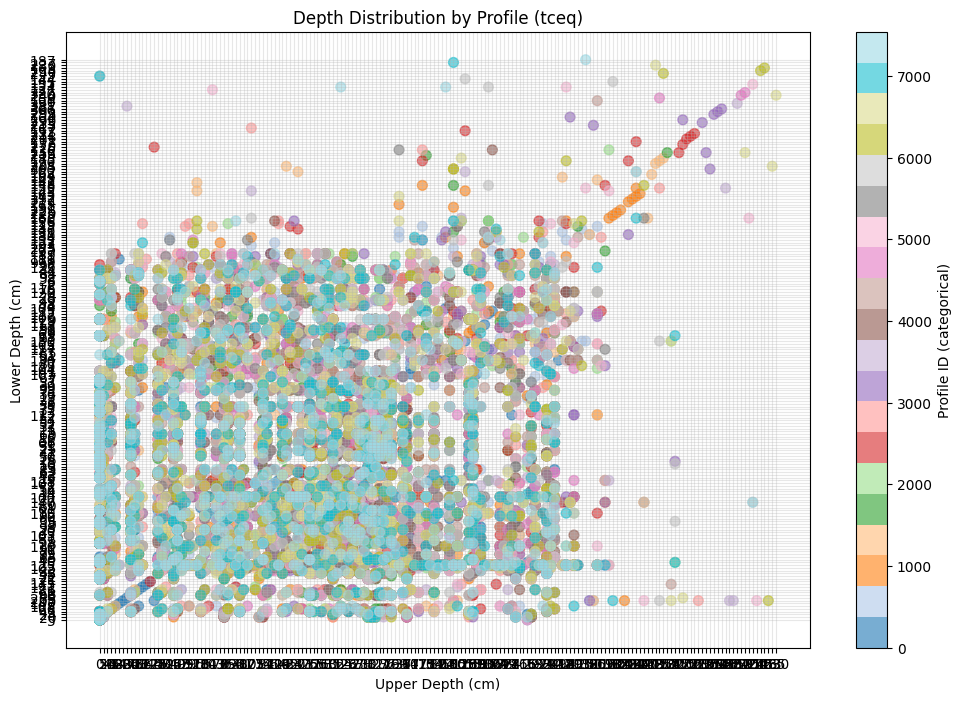

In [14]:
plot_scatter(tceq_df, title='Depth Distribution by Profile (tceq)')

INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using ca

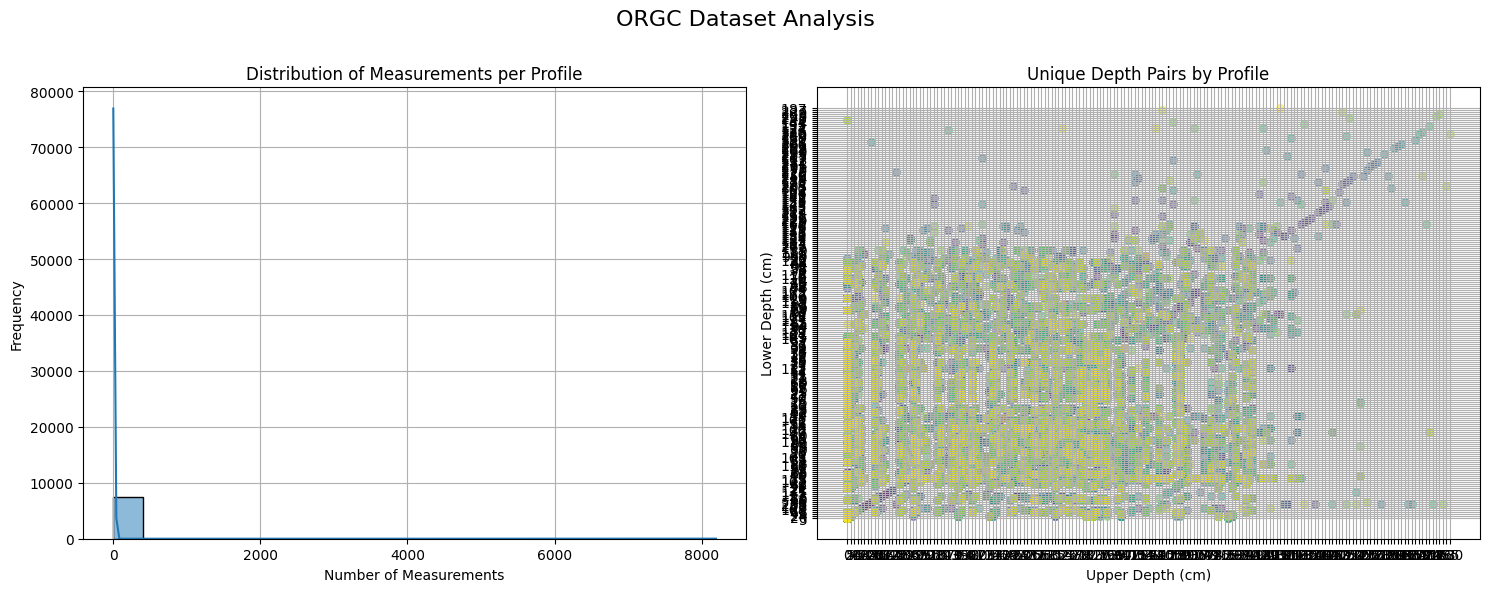

INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using ca

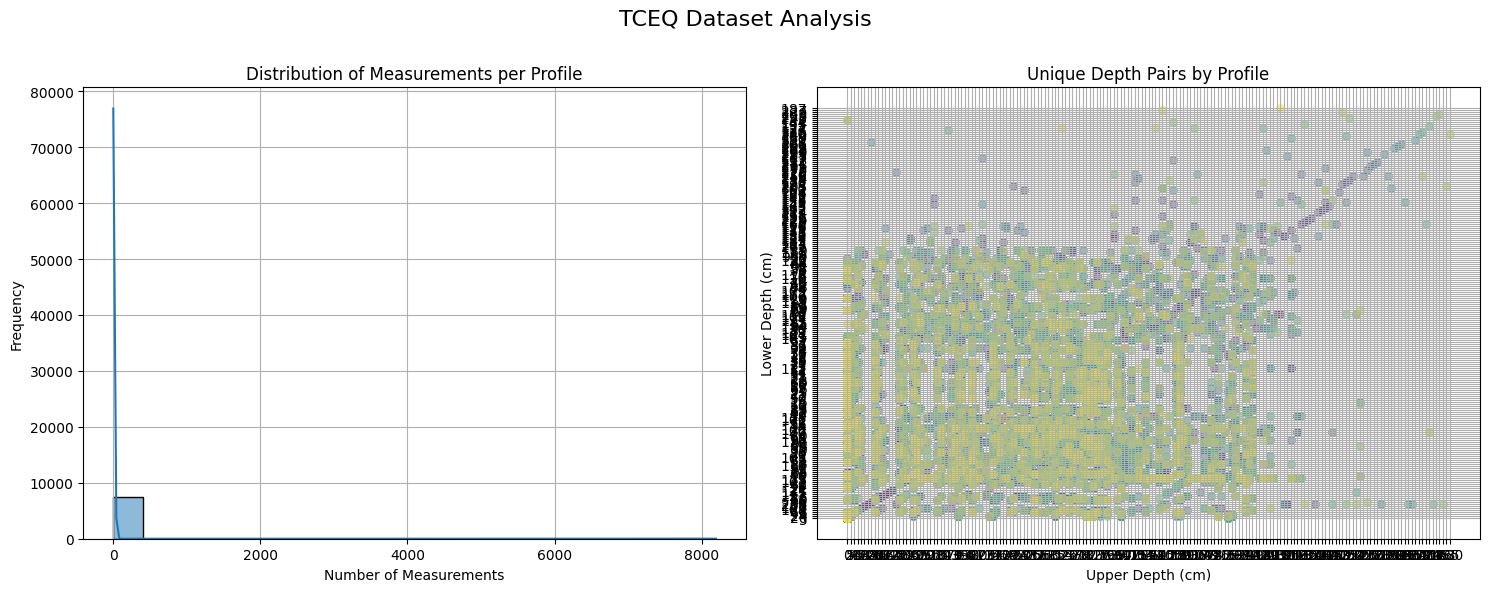

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def depth_analysis(df, title='Depth Analysis'):
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left plot: Distribution of number of measurements per profile
    depth_counts = df.groupby('profile_id').size()
    sns.histplot(depth_counts, bins=20, kde=True, ax=ax1)
    ax1.set_title('Distribution of Measurements per Profile')
    ax1.set_xlabel('Number of Measurements')
    ax1.set_ylabel('Frequency')
    ax1.grid(True)

    # Right plot: Unique depth pairs by profile
    profiles = df['profile_id'].unique()
    colors = plt.cm.viridis(np.linspace(0, 1, len(profiles)))
    
    for idx, profile in enumerate(profiles):
        profile_data = df[df['profile_id'] == profile]
        ax2.scatter(profile_data['upper_depth'], profile_data['lower_depth'], 
                   color=colors[idx], alpha=0.5, s=30)
    
    ax2.set_title('Unique Depth Pairs by Profile')
    ax2.set_xlabel('Upper Depth (cm)')
    ax2.set_ylabel('Lower Depth (cm)')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.suptitle(title, fontsize=16)
    plt.subplots_adjust(top=0.85)
    plt.show()

# Apply to both datasets
depth_analysis(orgc_df, "ORGC Dataset Analysis")
depth_analysis(tceq_df, "TCEQ Dataset Analysis")

In [16]:
def preprocessor_depth(df):
    # drop duplicates for same profile_id and depth
    df.drop_duplicates(subset=['profile_id', 'upper_depth', 'lower_depth'], inplace=True)
    logger.info(f"Number of records after dropping duplicates: {len(df)}")
    # check for missing values
    missing_values = df.isnull().sum()
    logger.info(f"Missing values in the dataset: {missing_values[missing_values > 0]}")
    # if there are missing values, drop them
    if missing_values.sum() > 0:
        df.dropna(inplace=True)
        logger.info(f"Number of records after dropping missing values: {len(df)}")
    
    # print final dataset info
    logger.info(f"Final number of records: {len(df)}")

    return df

In [17]:
orgc_df = preprocessor_depth(orgc_df)


INFO - Number of records after dropping duplicates: 21829
INFO - Missing values in the dataset: Series([], dtype: int64)
INFO - Final number of records: 21829


The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


In [18]:
tceq_df = preprocessor_depth(tceq_df)   

INFO - Number of records after dropping duplicates: 21829
INFO - Missing values in the dataset: Series([], dtype: int64)
INFO - Final number of records: 21829
